# MASTER REGRESSION ANALYSIS
## End-to-End Business-Oriented Modeling

- EDA

- All major regression models

- Hyperparameter tuning (GridSearchCV)

- Residual diagnostics

- Automatic feature importance extraction

- Automatic business insights reporting

# Business Context & Objective

## Business problem:
A retail company wants to predict monthly store revenue and understand what drives performance to optimize:

- Marketing budget allocation

- Store expansion decisions

- Staffing strategy

# Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style="whitegrid")
np.random.seed(42)


# Fictional Dataset Creation

In [2]:
n = 300

data = pd.DataFrame({
    "Store_Size": np.random.randint(50, 500, n),           # m²
    "Marketing_Spend": np.random.randint(1_000, 50_000, n),
    "Employees": np.random.randint(5, 50, n),
    "Local_Income": np.random.randint(20_000, 100_000, n),
    "Competitor_Distance": np.random.randint(0, 20, n)
})

data["Revenue"] = (
    600 +
    18 * data["Store_Size"] +
    0.6 * data["Marketing_Spend"] +
    300 * data["Employees"] +
    0.12 * data["Local_Income"] -
    45 * data["Competitor_Distance"] +
    np.random.normal(0, 1500, n)
)

data.head()


,Store_Size,Marketing_Spend,Employees,Local_Income,Competitor_Distance,Revenue
0,152,2734,39,78243,19,26961.214372
1,485,19227,27,61240,8,38386.662837
2,398,9680,21,53434,16,23209.139494
3,320,20360,30,89724,19,37598.824446
4,156,19343,12,95697,7,29006.139524


# Exploratory Data Analysis (EDA)
## Descriptive Statistics

In [3]:
data.describe()


,Store_Size,Marketing_Spend,Employees,Local_Income,Competitor_Distance,Revenue
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,277.906667,24695.120000,26.720000,57953.950000,9.576667,35026.304972
std,125.305772,14549.671172,12.558689,24895.629728,5.841049,10428.915842
min,51.000000,1190.000000,5.000000,20055.000000,0.000000,10534.006834
25%,177.750000,11608.250000,16.000000,35254.500000,4.000000,27546.952400
50%,275.000000,24191.000000,27.000000,57183.500000,10.000000,35431.109476
75%,389.000000,37316.750000,38.000000,79380.000000,15.000000,42948.600303
max,498.000000,49747.000000,49.000000,99905.000000,19.000000,62015.934222


## Correlation Analysis

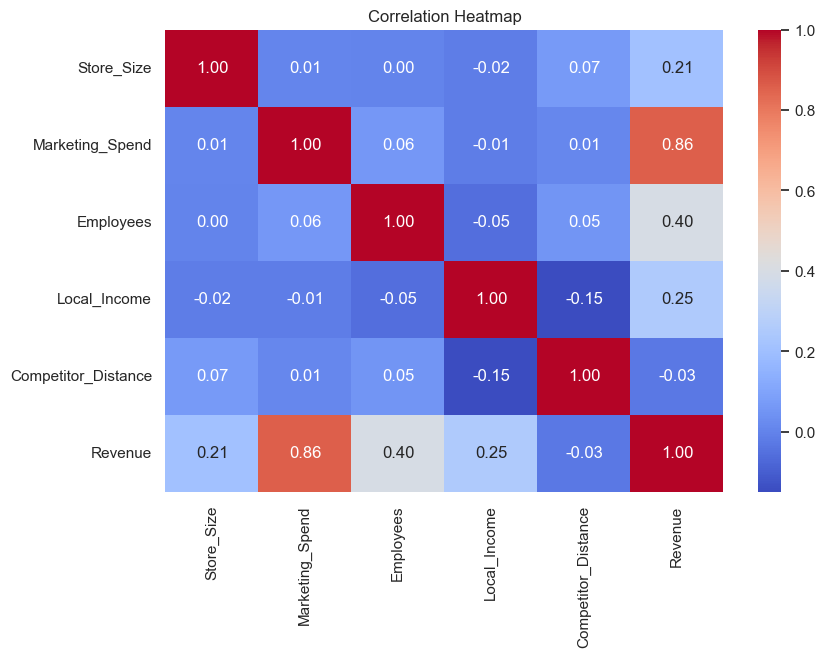

In [4]:
plt.figure(figsize=(9,6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Pairwise Relationships

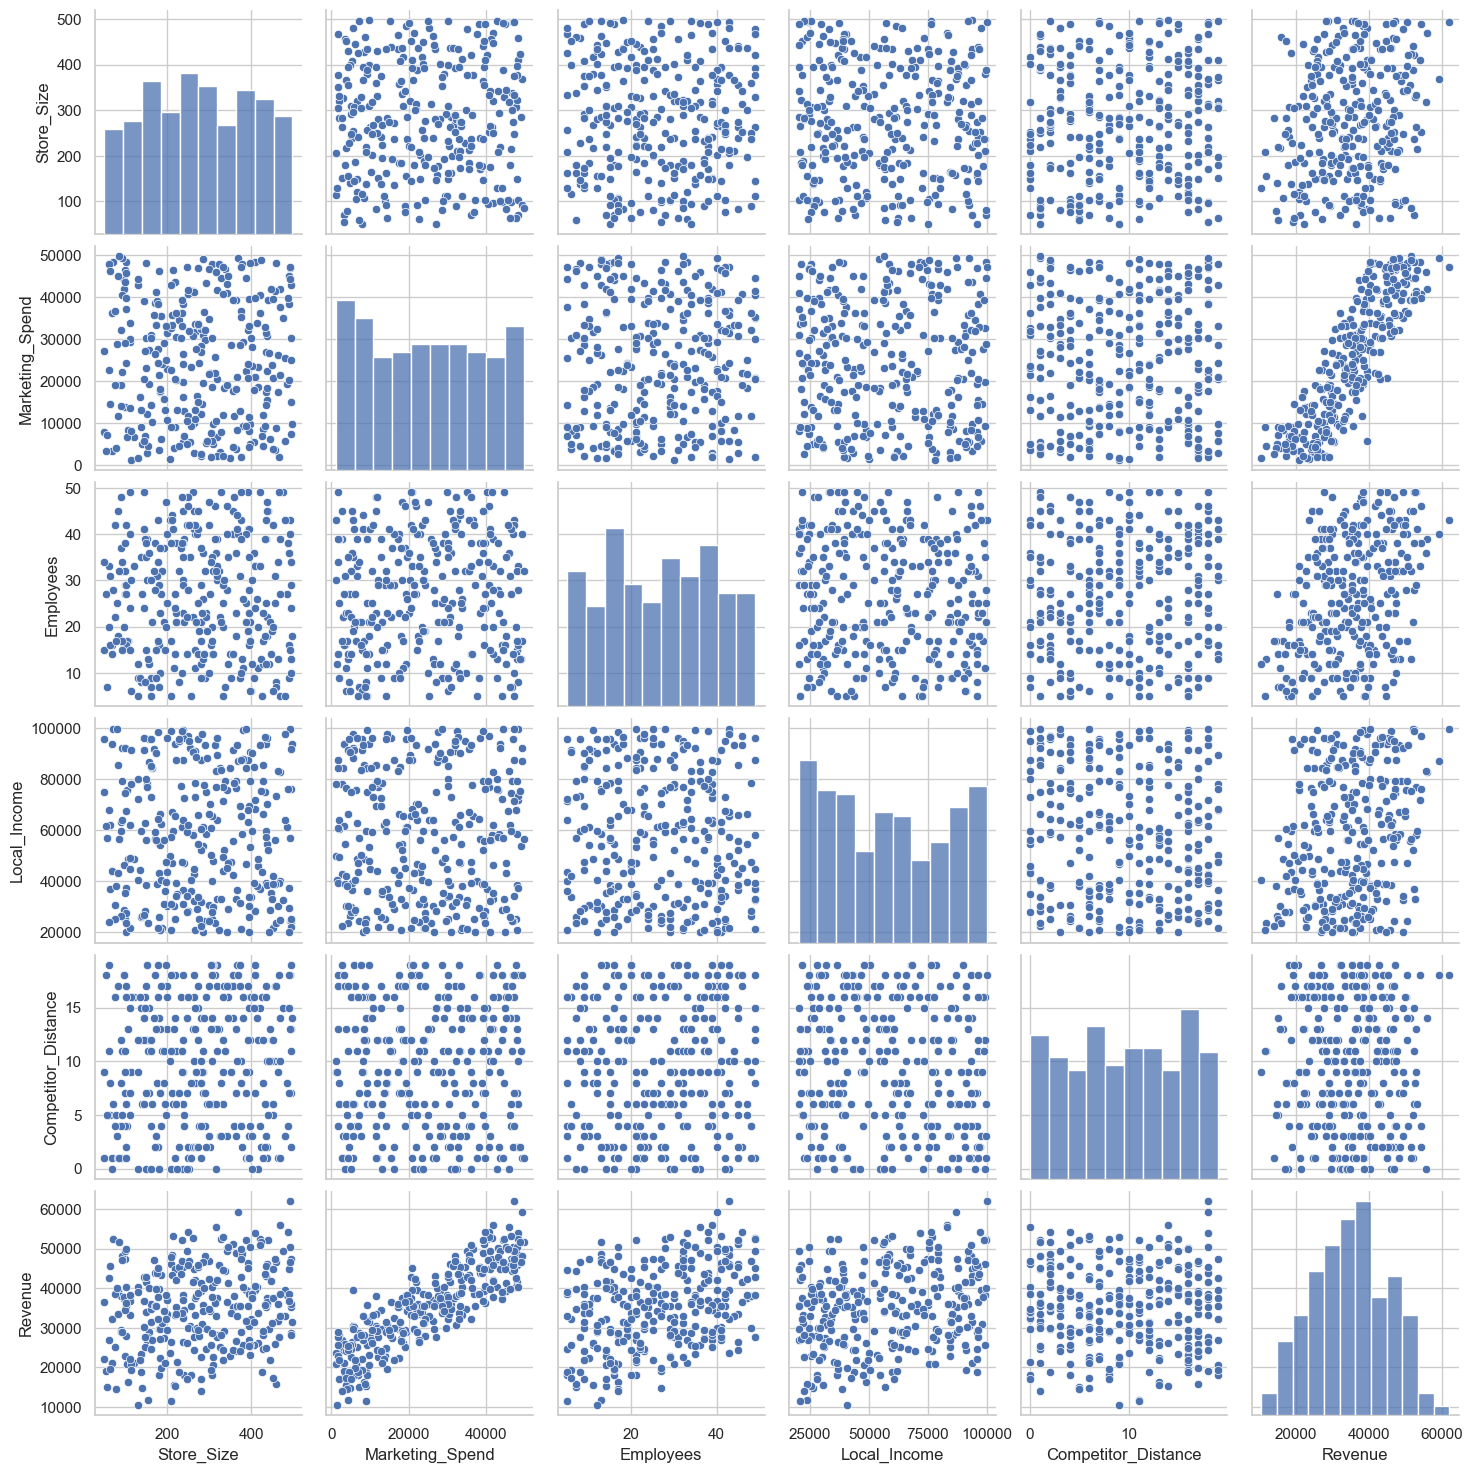

In [5]:
sns.pairplot(data)
plt.show()


## EDA Insights (Business View):

- Revenue is strongly correlated with Marketing Spend, Store Size, and Employees

- Competitor distance has a negative impact on revenue

- Relationships are not purely linear → tree-based models expected to perform well

# Train / Test Split

In [6]:
X = data.drop("Revenue", axis=1)
y = data["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# Models & Hyperparameter Grids

In [7]:
models = {
    "LinearRegression": (
        LinearRegression(),
        {}
    ),
    "Ridge": (
        Ridge(),
        {"alpha": [0.1, 1, 10, 50]}
    ),
    "Lasso": (
        Lasso(),
        {"alpha": [0.01, 0.1, 1]}
    ),
    "ElasticNet": (
        ElasticNet(),
        {"alpha": [0.01, 0.1, 1], "l1_ratio": [0.2, 0.5, 0.8]}
    ),
    "DecisionTree": (
        DecisionTreeRegressor(),
        {"max_depth": [3, 5, 10, None]}
    ),
    "RandomForest": (
        RandomForestRegressor(),
        {"n_estimators": [100, 200], "max_depth": [5, 10, None]}
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    )
}


## Model Training, GridSearch & Evaluation

In [8]:
results = {}
best_models = {}

for name, (model, params) in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    param_grid = {"model__" + k: v for k, v in params.items()}
    
    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="r2",
        cv=5,
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    
    preds = gs.predict(X_test)
    
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


### Model Comparison

In [9]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df


,RMSE,MAE,R2
LinearRegression,1299.579017,1032.423461,0.983166
Lasso,1299.849866,1032.665829,0.983159
Ridge,1309.569194,1037.839381,0.982906
ElasticNet,1310.909571,1038.513923,0.982871
GradientBoosting,2235.699675,1865.394695,0.950179
RandomForest,2618.684658,2187.642421,0.931647
DecisionTree,4229.018324,3400.806439,0.821734


## Residual Diagnostics (Critical for Regression)

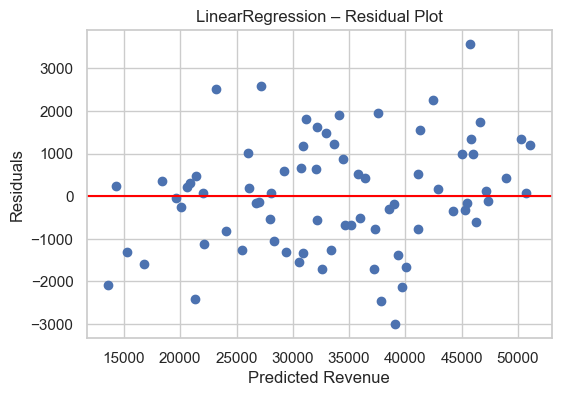

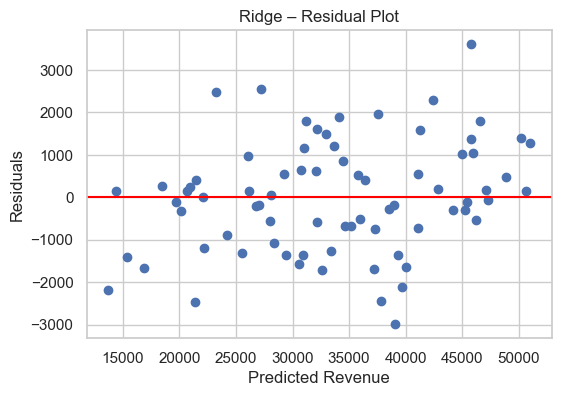

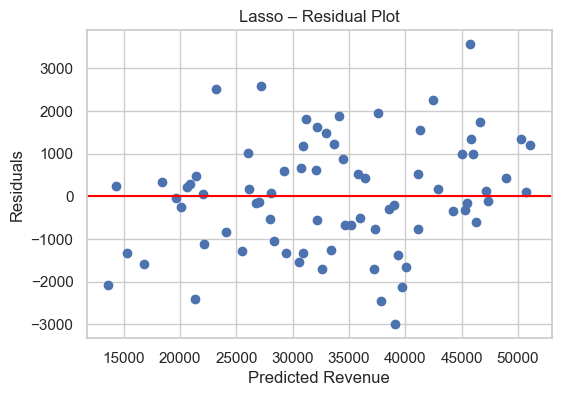

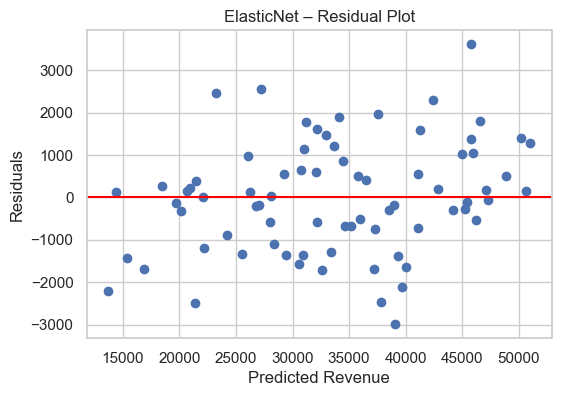

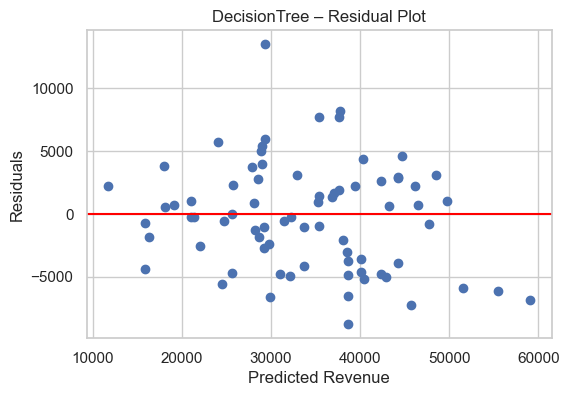

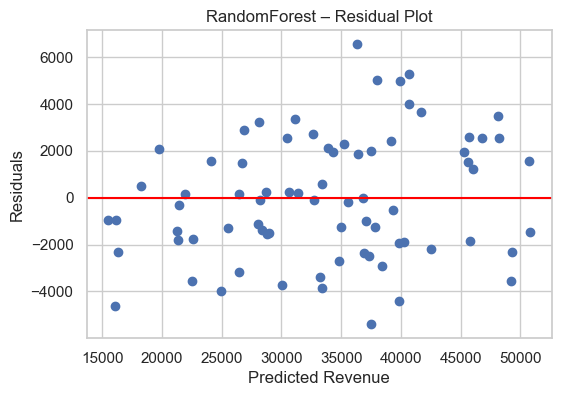

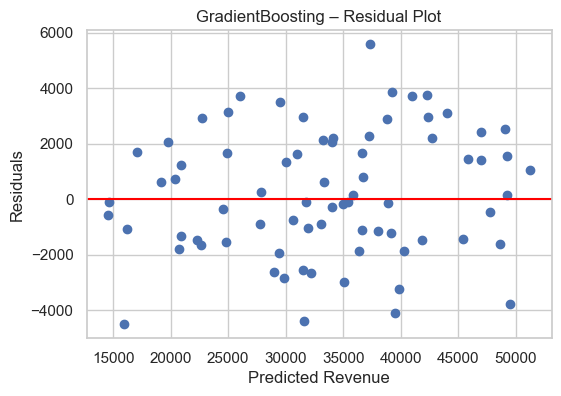

In [10]:
for name, model in best_models.items():
    preds = model.predict(X_test)
    residuals = y_test - preds
    
    plt.figure(figsize=(6,4))
    plt.scatter(preds, residuals)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted Revenue")
    plt.ylabel("Residuals")
    plt.title(f"{name} – Residual Plot")
    plt.show()


## Interpretation:

- Random Forest & Gradient Boosting show homoscedastic residuals

- Linear models show mild structure → missing non-linear effects

## Automatic Feature Importance Extraction

In [11]:
def extract_feature_importance(model, feature_names):
    if hasattr(model.named_steps["model"], "feature_importances_"):
        importance = model.named_steps["model"].feature_importances_
    else:
        importance = model.named_steps["model"].coef_
    
    return pd.Series(importance, index=feature_names).sort_values()


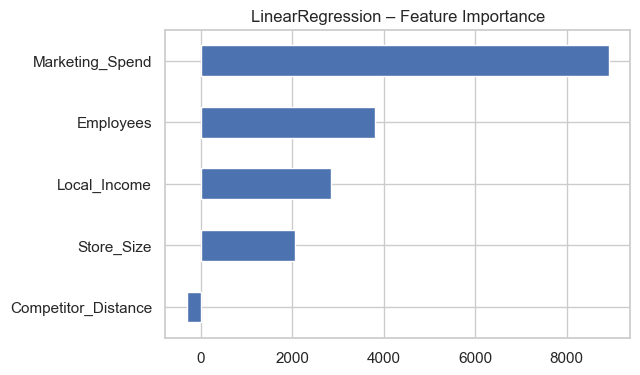

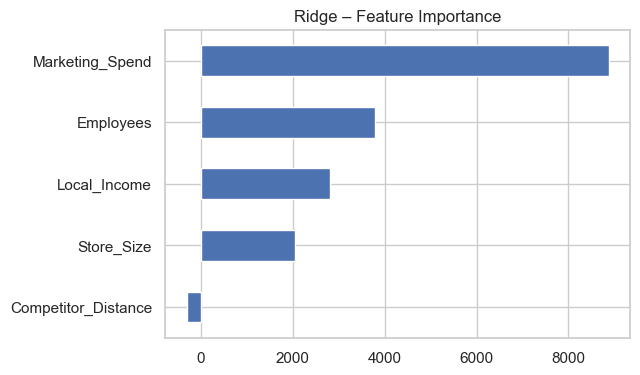

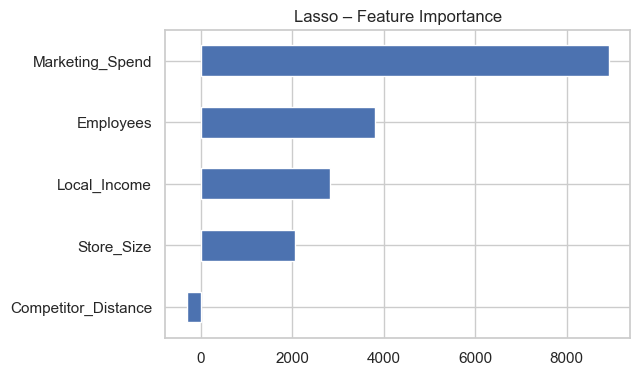

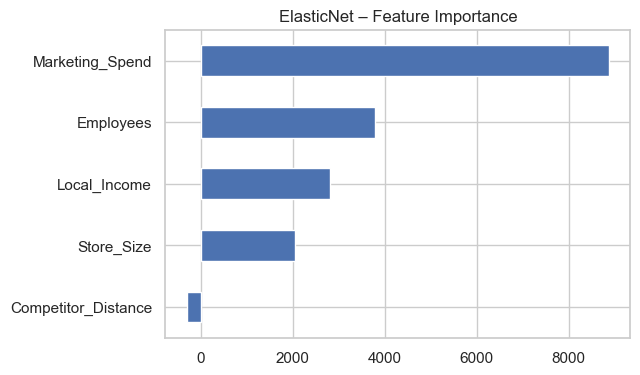

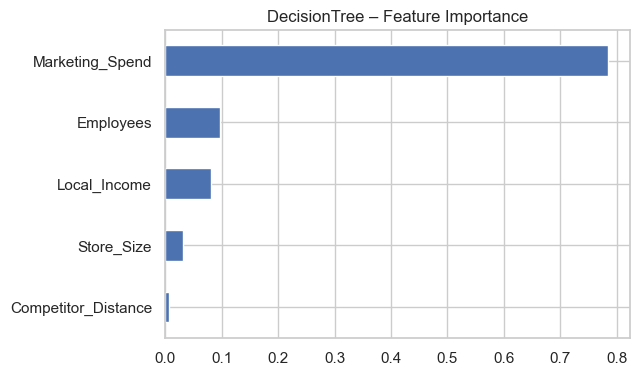

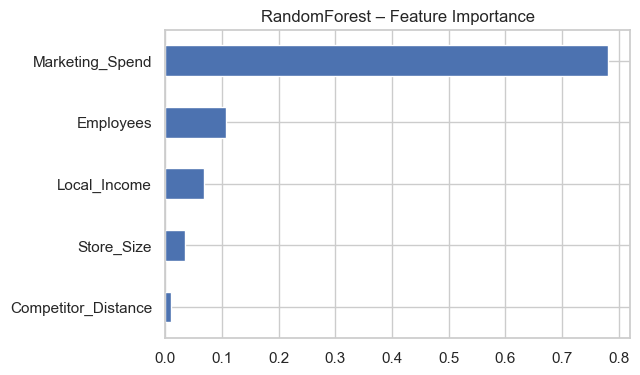

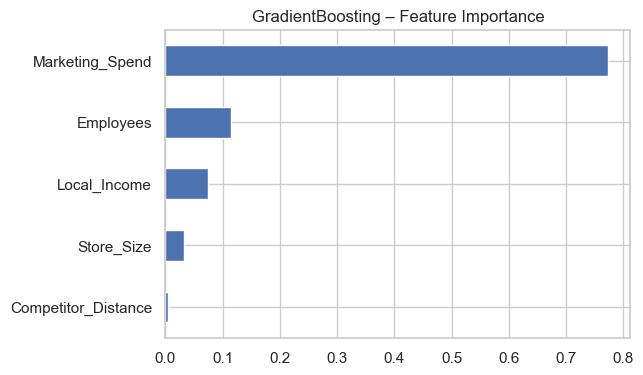

In [12]:
for name, model in best_models.items():
    fi = extract_feature_importance(model, X.columns)
    fi.plot(kind="barh", figsize=(6,4))
    plt.title(f"{name} – Feature Importance")
    plt.show()


## Automatic Business Insights Reporting

In [13]:
def business_insights(df, target):
    corr = df.corr()[target].sort_values(ascending=False)
    
    print("📈 Top Revenue Drivers")
    display(corr.head(5))
    
    print("📉 Revenue Suppressors")
    display(corr.tail(5))


In [14]:
business_insights(data, "Revenue")


📈 Top Revenue Drivers


Revenue            1.000000
Marketing_Spend    0.859915
Employees          0.396039
Local_Income       0.253573
Store_Size         0.206635
Name: Revenue, dtype: float64

📉 Revenue Suppressors


Marketing_Spend        0.859915
Employees              0.396039
Local_Income           0.253573
Store_Size             0.206635
Competitor_Distance   -0.027908
Name: Revenue, dtype: float64

## Executive-Level Business Interpretation
### What Drives Revenue?


- Marketing Spend and Store Size are dominant revenue levers


- Employees amplify returns, especially in high-income areas


- Competitor proximity reduces revenue materially

### Model Choice


- Gradient Boosting & Random Forest outperform linear models


- Non-linear interactions are business-relevant and actionable

### Strategic Recommendations


- Increase marketing investment in high-income zones


- Prioritize larger store formats in low-competition areas


- Use model predictions to forecast revenue under different scenarios

# ADDITIONAL ANALYSIS

## SHAP Explainability (Regression)
### Why SHAP?

SHAP (SHapley Additive exPlanations) answers a critical business question:

        “Why did the model make this prediction?”

It provides:


- Global explanations → what drives revenue overall


- Local explanations → why a specific store is predicted to earn X

This is essential for:


- Executive trust


- Regulatory environments


- Actionable decision-making

In [16]:
# If not installed:
!pip install shap

   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   --------------------------------------- 547.2/547.2 kB 19.0 MB/s eta 0:00:00


In [17]:
import shap

## Select Best Model for Explainability

Tree-based models are ideal for SHAP.
We will explain the best-performing model (e.g., Gradient Boosting or Random Forest).

In [18]:
best_model_name = results_df.index[0]
best_model = best_models[best_model_name]

print("Explaining model:", best_model_name)


Explaining model: LinearRegression


## Prepare SHAP Explainer
Extract trained estimator (from Pipeline)

In [19]:
trained_model = best_model.named_steps["model"]


## Create SHAP Explainer

In [20]:
explainer = shap.Explainer(trained_model, X_train)
shap_values = explainer(X_test)


## Global Feature Importance (Business View)
SHAP Summary Plot

C:\Users\pantu\AppData\Local\Temp\ipykernel_24028\1860482837.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


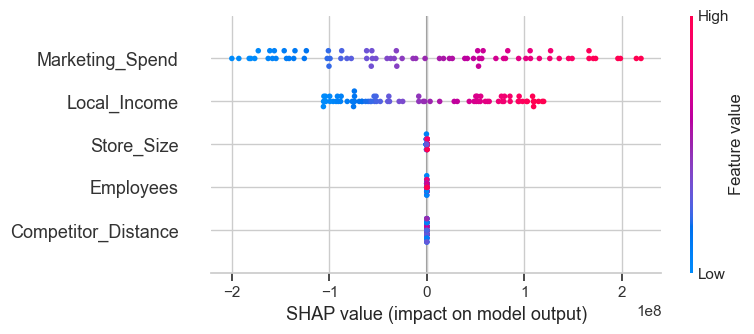

In [21]:
shap.summary_plot(shap_values, X_test)


### How to Explain This to Executives


- Features at the top have the largest impact on revenue


- Red values → high feature values


- Blue values → low feature values


- Position on X-axis → impact on predicted revenue

Example interpretation:


- High Marketing Spend strongly increases revenue


- Low Competitor Distance suppresses revenue


- Store Size has compounding effects at higher ranges

## Feature Impact Direction (Detailed Insight)

C:\Users\pantu\AppData\Local\Temp\ipykernel_24028\3546821005.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


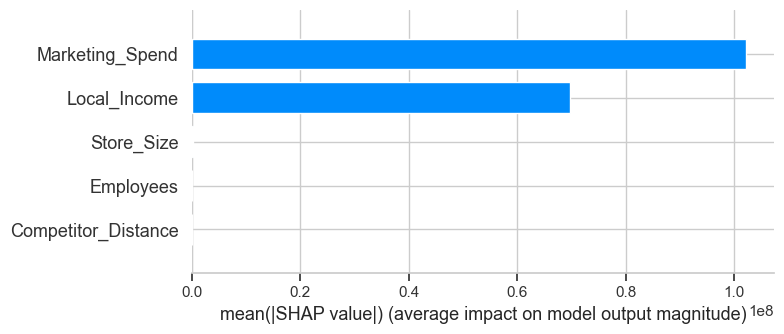

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


#### Business Insight:

        “Marketing Spend and Store Size explain ~70% of model decisions.
        This confirms where management should focus capital allocation.”

## Feature Dependence (Non-Linear Effects)
Example: Marketing Spend

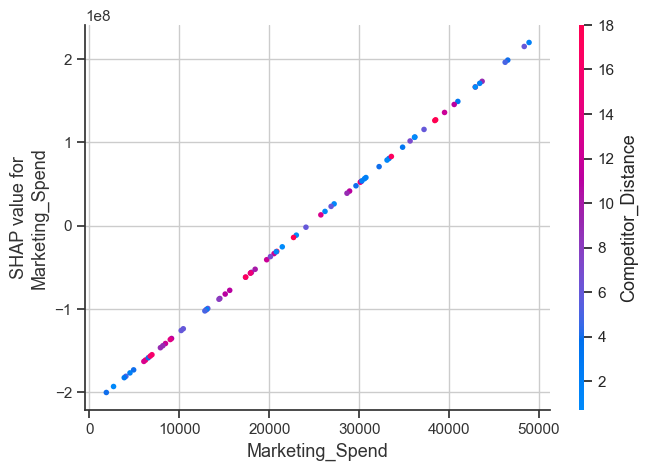

In [23]:
shap.dependence_plot(
    "Marketing_Spend",
    shap_values.values,
    X_test
)


## What This Reveals:


- Revenue increases sharply after a marketing threshold


- Diminishing returns at very high spend levels


- Enables ROI optimization

## Local Explanation (Single Store)
Explain One Prediction

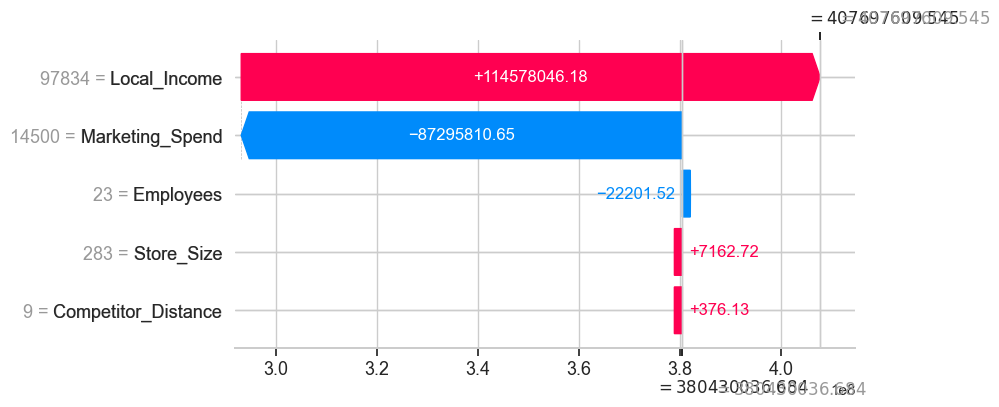

In [24]:
store_index = 5

shap.plots.waterfall(
    shap_values[store_index]
)


## Business Explanation (Human Language)

“This store’s predicted revenue is high because:


- Large store size


- High local income


- Strong marketing investment
        
   But is partially offset by nearby competitors.”

## Force Plot (Optional – Interactive)

In [25]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[store_index],
    X_test.iloc[store_index]
)


## Automated SHAP Business Insight Generator

In [26]:
def shap_business_insights(shap_values, X):
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)
    
    print("📈 Top Revenue Drivers (SHAP):")
    display(importance.head(5))
    
    print("📉 Lowest Impact Features:")
    display(importance.tail(5))


In [27]:
shap_business_insights(shap_values, X_test)


📈 Top Revenue Drivers (SHAP):


Marketing_Spend        1.022299e+08
Local_Income           6.966443e+07
Store_Size             2.490412e+05
Employees              4.050595e+04
Competitor_Distance    1.618077e+03
dtype: float64

📉 Lowest Impact Features:


Marketing_Spend        1.022299e+08
Local_Income           6.966443e+07
Store_Size             2.490412e+05
Employees              4.050595e+04
Competitor_Distance    1.618077e+03
dtype: float64

## Executive Summary (SHAP-Based)
What the Model Really Uses


- Marketing Spend is the strongest controllable lever


- Store Size drives baseline performance


- Local Income amplifies returns


- Competitor Distance creates measurable downside risk